# Notebook 11: Temporal & Directional Parameters — Drifting Gratings (Session A)

Companion to **05b** (spatial σ, θ, κ from sparse noise). This notebook extracts the
**temporal / joint space-time** Lindeberg parameters from the Session A drifting-grating
stimulus, using the same architecture: estimation logic lives in
`src/rf_analysis/drifting_gratings.py`, this notebook orchestrates the batch over containers.

**Four quantities** (per the 23-June analysis):

| # | Parameter | Status | Read from |
|---|-----------|--------|-----------|
| i   | preferred **direction** (+ DSI/gDSI, OSI/gOSI) | **estimated — solid** | direction tuning at preferred TF |
| ii  | **temporal scale** τ | estimated — *convention-dependent* | TF tuning peak (`τ = 1/(2πf_pref)`) |
| iii | **temporal order** (sustained/low-pass 0 vs transient/band-pass 1) | **estimated — solid (shape)** | shape of the TF curve |
| iv  | preferred **velocity** | **derived — soft** | `TF_pref / SF` (single SF = 0.04 cpd) |

Direction and τ/order are the two that come clean. **Velocity is the soft one** — the protocol
uses a single spatial frequency, so it is reported as *"preferred TF at fixed SF"*, not a measured speed.

**GCaMP6f caveat** (baked into the diagnostics, not corrected): the indicator low-passes the calcium
response, attenuating high drift TFs → preferred TF biased low, τ biased high, cells biased toward
*sustained*. Cells still rising at 15 Hz are flagged `pref_tf_at_ceiling`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, warnings, time
from pathlib import Path

sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))
from rf_analysis.drifting_gratings import (
    extract_dg_responses, fit_temporal_parameters,
    extract_temporal_parameters, batch_extract_temporal_parameters,
    SF_DG, DG_DIRECTIONS, DG_TFS,
)
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
warnings.filterwarnings('ignore')

print('✓ Imports successful')
print(f'  SF (fixed)  : {SF_DG} cpd')
print(f'  Directions  : {DG_DIRECTIONS.astype(int)}')
print(f'  Temporal fq : {DG_TFS} Hz')

✓ Imports successful
  SF (fixed)  : 0.04 cpd
  Directions  : [  0  45  90 135 180 225 270 315]
  Temporal fq : [ 1.  2.  4.  8. 15.] Hz


In [2]:
base_dir    = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir   = base_dir / 'data' / 'cache'
lists_dir   = base_dir / 'data' / 'experiment_lists'
outputs_dir = base_dir / 'outputs' / 'rf_params'
dg_dir      = outputs_dir / 'drifting_gratings'   # ← temporal outputs, separate from ridge/STA
dg_dir.mkdir(parents=True, exist_ok=True)

manifest_path = str(cache_dir / 'manifest.json')
boc = BrainObservatoryCache(manifest_file=manifest_path)

# Same experiment metadata as 05b
batch_df       = pd.read_csv(lists_dir / 'all_l23_excitatory_experiments.csv')
container_meta = pd.read_csv(lists_dir / 'container_neuron_counts.csv')
verify_df      = pd.read_csv(lists_dir / 'downloaded_all_l23_excitatory_experiments.csv')
downloaded     = set(verify_df[verify_df['exists']]['experiment_id'].tolist())
complete_ids   = set(container_meta['container_id'].tolist())

# Drifting gratings live ONLY in Session A (three_session_A)
session_a = batch_df[
    batch_df['session_type'].str.contains('A') &
    batch_df['id'].isin(downloaded) &
    batch_df['experiment_container_id'].isin(complete_ids)
].copy()

print(f'✓ Complete containers : {len(complete_ids)}')
print(f'✓ Session A to process: {len(session_a)}')
print(f'✓ Temporal output dir : {dg_dir}')

✓ Complete containers : 17
✓ Session A to process: 17
✓ Temporal output dir : /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/drifting_gratings


---
## Part 1: Batch temporal extraction

One `batch_extract_temporal_parameters(dataset, cell_ids)` call per container — single ΔF/F read,
vectorised per-trial responses across cells, cheap tuning fit looped per neuron. Same
skip-if-cached / per-container-CSV pattern as 05b. Cortical (x, y) from ROI centroids is carried
through so temporal parameters can later get the same salt-and-pepper spatial-organisation test.

**Inclusion criterion:** a neuron is kept if it is significantly responsive to the grating set
(one-way ANOVA across the 40 dir×TF conditions, `p < 0.05`). This is the temporal analogue of the
spatial `R² ≥ 0.3` gate. *This is a decision point — see the flags at the end of the notebook.*

In [3]:
REQUIRE_RESPONSIVE  = True     # ANOVA p<0.05 gate (analogue of R²≥0.3)
BANDPASS_THRESHOLD  = 0.15     # band-pass index cut: >thr → transient (order 1)
PIXEL_SIZE_UM       = 0.78     # μm per pixel, standard Allen 2P (matches 05b)

batch_log = []
t_start   = time.time()

for row_i, exp_row in session_a.iterrows():
    container_id = exp_row['experiment_container_id']
    exp_id       = exp_row['id']
    cre_line     = exp_row['cre_line']
    depth        = exp_row['imaging_depth']

    out_file = dg_dir / f'dg_params_container_{container_id}.csv'

    if out_file.exists():
        df_existing = pd.read_csv(out_file)
        print(f'  [SKIP] Container {container_id}: {len(df_existing)} neurons (cached)')
        batch_log.append({'container_id': container_id, 'exp_id': exp_id,
                          'cre_line': cre_line, 'depth': depth,
                          'n_success': len(df_existing), 'status': 'cached'})
        continue

    print(f'\n[{row_i+1}/{len(session_a)}] Container {container_id}'
          f'  |  exp {exp_id}  |  {cre_line}  |  {depth} μm')

    try:
        t0       = time.time()
        dataset  = boc.get_ophys_experiment_data(exp_id)
        cell_ids = dataset.get_cell_specimen_ids()
        print(f'  Neurons in container: {len(cell_ids)}')

        results = batch_extract_temporal_parameters(
            dataset, cell_ids,
            require_responsive=REQUIRE_RESPONSIVE,
            bandpass_threshold=BANDPASS_THRESHOLD,
        )

        if not results:
            print('  WARNING: 0 neurons responsive — check data')
            batch_log.append({'container_id': container_id, 'exp_id': exp_id,
                              'cre_line': cre_line, 'depth': depth,
                              'n_success': 0, 'status': 'no_results'})
            continue

        df_out = pd.DataFrame(results)

        # --- Cortical xy from ROI centroids (same as 05b) ---
        roi_masks   = dataset.get_roi_mask_array()
        roi_ids_all = list(dataset.get_cell_specimen_ids())
        cx_um, cy_um = [], []
        for cid in df_out['cell_id'].tolist():
            idx  = roi_ids_all.index(cid)
            ys, xs = np.where(roi_masks[idx] > 0)
            cx_um.append(xs.mean() * PIXEL_SIZE_UM if len(xs) else np.nan)
            cy_um.append(ys.mean() * PIXEL_SIZE_UM if len(ys) else np.nan)
        df_out['cortex_x_um'] = cx_um
        df_out['cortex_y_um'] = cy_um

        # --- Container metadata ---
        df_out['container_id'] = container_id
        df_out['exp_id']       = exp_id
        df_out['cre_line']     = cre_line
        df_out['depth_um']     = depth

        # dir_tuning / tf_tuning are lists → store as JSON-ish strings
        for col in ('dir_tuning', 'tf_tuning'):
            df_out[col] = df_out[col].apply(lambda v: ';'.join(f'{x:.5g}' for x in v))

        df_out.to_csv(out_file, index=False)
        elapsed = time.time() - t0
        n_total, n_resp = len(cell_ids), len(df_out)
        print(f'  ✓ {n_resp}/{n_total} responsive  ({100*n_resp/n_total:.1f}%)  |  {elapsed:.1f}s')
        batch_log.append({'container_id': container_id, 'exp_id': exp_id,
                          'cre_line': cre_line, 'depth': depth,
                          'n_total': n_total, 'n_success': n_resp,
                          'elapsed_s': round(elapsed, 1), 'status': 'done'})

    except Exception as e:
        print(f'  ERROR container {container_id}: {e}')
        batch_log.append({'container_id': container_id, 'exp_id': exp_id,
                          'cre_line': cre_line, 'depth': depth,
                          'n_success': 0, 'status': f'error: {str(e)[:80]}'})

log_df = pd.DataFrame(batch_log)
print(f'\n✓ Batch complete — {(time.time()-t_start)/60:.1f} min')
print(f'  Done: {(log_df["status"]=="done").sum()}  '
      f'Cached: {(log_df["status"]=="cached").sum()}  '
      f'Errors: {log_df["status"].astype(str).str.startswith("error").sum()}')

  [SKIP] Container 650389885: 139 neurons (cached)
  [SKIP] Container 666589599: 61 neurons (cached)
  [SKIP] Container 511510670: 185 neurons (cached)
  [SKIP] Container 680156909: 306 neurons (cached)
  [SKIP] Container 661437138: 81 neurons (cached)
  [SKIP] Container 688678764: 421 neurons (cached)
  [SKIP] Container 511510855: 168 neurons (cached)
  [SKIP] Container 653125128: 124 neurons (cached)
  [SKIP] Container 652842570: 126 neurons (cached)
  [SKIP] Container 511510650: 111 neurons (cached)
  [SKIP] Container 661732156: 86 neurons (cached)
  [SKIP] Container 511507650: 136 neurons (cached)
  [SKIP] Container 701412138: 44 neurons (cached)
  [SKIP] Container 511510736: 86 neurons (cached)
  [SKIP] Container 511509529: 147 neurons (cached)
  [SKIP] Container 682734790: 269 neurons (cached)
  [SKIP] Container 511510718: 141 neurons (cached)

✓ Batch complete — 0.0 min
  Done: 0  Cached: 17  Errors: 0


In [4]:
# --- Combine all container CSVs ---
csvs = sorted(dg_dir.glob('dg_params_container_*.csv'))
dg_df = pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True)
print(f'✓ Combined: {len(dg_df)} responsive neurons across {dg_df.container_id.nunique()} containers')

# Reattach tuning vectors as arrays for downstream use
for col in ('dir_tuning', 'tf_tuning'):
    dg_df[col] = dg_df[col].apply(lambda s: np.array([float(x) for x in str(s).split(';')]) if isinstance(s, str) else s)

dg_df.to_csv(dg_dir / 'dg_params_all_containers.csv', index=False)
dg_df[['cell_id','pref_dir_deg','pref_tf_hz','temporal_order','bandpass_index',
       'dsi','gdsi','osi','gosi','tau_char_ms','velocity_deg_s',
       'pref_tf_at_ceiling','anova_p']].head()

✓ Combined: 2631 responsive neurons across 17 containers


,cell_id,pref_dir_deg,pref_tf_hz,temporal_order,bandpass_index,dsi,gdsi,osi,gosi,tau_char_ms,velocity_deg_s,pref_tf_at_ceiling,anova_p
0,517408412,270.0,2.0,1,0.283082,0.322221,0.259929,0.227037,0.064997,79.577472,50.0,False,2.284174e-02
1,517407360,135.0,1.0,0,0.000000,0.656524,0.384013,0.553051,0.218167,159.154943,25.0,False,4.795999e-04
2,517408416,90.0,2.0,1,0.391781,0.385283,0.123830,0.823155,0.632626,79.577472,50.0,False,6.783025e-04
3,517408289,180.0,2.0,1,0.302295,0.328025,0.094729,1.000000,0.689690,79.577472,50.0,False,6.401993e-05
4,517406523,315.0,2.0,0,0.040030,0.444940,0.441337,0.996604,0.985720,79.577472,50.0,False,6.136593e-120


---
## Part 2: First-look distributions (sanity, not analysis)

Quick population sanity checks so the extraction can be trusted before the real analysis notebook.
Nothing here is a manuscript claim — it is a "does the machinery produce sane numbers" pass:
preferred-direction coverage (expect all 8 bins populated), preferred-TF histogram (watch for a
15 Hz pile-up = GCaMP6f ceiling), sustained/transient split, and the DSI distribution.

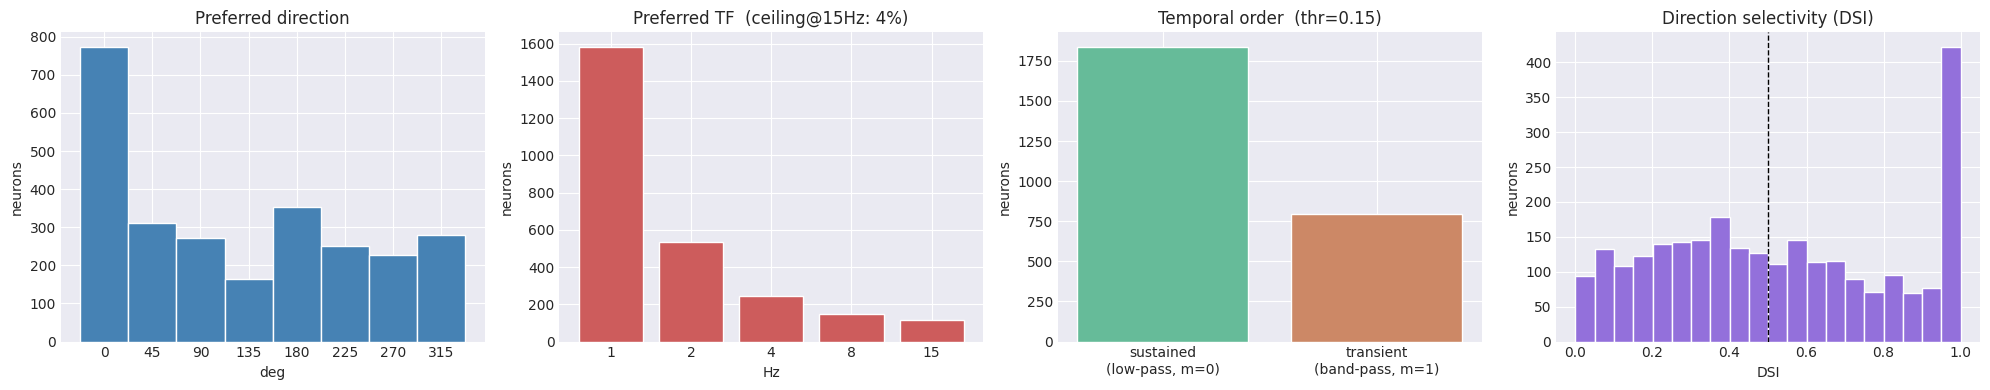

Responsive neurons        : 2631
Median DSI / gDSI         : 0.50 / 0.32
Transient (order 1) frac  : 30.2%
Pref-TF at ceiling (15Hz) : 4.4%  ← GCaMP6f caveat magnitude
Median τ_char / velocity  : 159 ms / 25 deg/s


In [5]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4))

# (1) preferred direction
ax[0].hist(dg_df['pref_dir_deg'], bins=np.arange(-22.5, 360, 45), color='steelblue', edgecolor='w')
ax[0].set(title='Preferred direction', xlabel='deg', ylabel='neurons')
ax[0].set_xticks(DG_DIRECTIONS)

# (2) preferred TF — flag ceiling pile-up
tf_counts = dg_df['pref_tf_hz'].value_counts().reindex(DG_TFS, fill_value=0)
ceil_frac = dg_df['pref_tf_at_ceiling'].mean()
ax[1].bar(range(len(DG_TFS)), tf_counts.values, color='indianred', edgecolor='w')
ax[1].set(title=f'Preferred TF  (ceiling@15Hz: {ceil_frac:.0%})', xlabel='Hz', ylabel='neurons')
ax[1].set_xticks(range(len(DG_TFS))); ax[1].set_xticklabels([f'{t:g}' for t in DG_TFS])

# (3) temporal order
oc = dg_df['temporal_order'].value_counts().reindex([0, 1], fill_value=0)
ax[2].bar(['sustained\n(low-pass, m=0)', 'transient\n(band-pass, m=1)'], oc.values,
          color=['#6b9', '#c86'], edgecolor='w')
ax[2].set(title=f'Temporal order  (thr={BANDPASS_THRESHOLD})', ylabel='neurons')

# (4) DSI
ax[3].hist(dg_df['dsi'].clip(0, 1), bins=20, color='mediumpurple', edgecolor='w')
ax[3].axvline(0.5, ls='--', c='k', lw=1)
ax[3].set(title='Direction selectivity (DSI)', xlabel='DSI', ylabel='neurons')

plt.tight_layout(); plt.show()

print(f"Responsive neurons        : {len(dg_df)}")
print(f"Median DSI / gDSI         : {dg_df['dsi'].median():.2f} / {dg_df['gdsi'].median():.2f}")
print(f"Transient (order 1) frac  : {(dg_df['temporal_order']==1).mean():.1%}")
print(f"Pref-TF at ceiling (15Hz) : {ceil_frac:.1%}  ← GCaMP6f caveat magnitude")
print(f"Median τ_char / velocity  : {dg_df['tau_char_ms'].median():.0f} ms / "
      f"{dg_df['velocity_deg_s'].median():.0f} deg/s")

---
## Part 3: temporal vector for a specific neuron set — the m=1 join

The population run above extracts *every* responsive neuron per container. But the
immediate use is the reverse query: **give me the temporal vector for a named cell set**
— e.g. the 31 m=1 simple cells in `m1_neuron_dataset` — so it sits beside their spatial
σ/θ/κ. This mirrors **nb05g Cell 6** exactly (`container_to_exp` + `dataset_cache` +
`by_container` loop). Two deliberate differences:

- `require_responsive=False` — keep **every** requested cell so the result joins 1:1 onto
  the dataset; grating-responsiveness is carried as a *flag* (`responsive`), not a drop filter.
- Session A `container_to_exp` — drifting gratings live in Session A, not C. The join is valid
  because `cell_specimen_id` is the permanent, cross-session Allen identifier within a container.

Cells present in Session C but **not matched in Session A** are silently absent from the drifting-
grating experiment (the safe loader drops them) → their temporal columns land as `NaN` after the
left-merge. That is expected, not an error.

In [6]:
# --- Temporal vector for a named cell set (default: the m=1 dataset) ---
target_csv = outputs_dir / 'order_full_v2' / 'rf_gallery' / 'm1_neuron_dataset.csv'
target_df  = pd.read_csv(target_csv)
target_df['container_id'] = target_df['container_id'].astype(int)

# Session A container→experiment map (drifting gratings are Session A)
container_to_exp_A = dict(zip(session_a['experiment_container_id'], session_a['id']))

dataset_cache, temporal_records = {}, []
by_container = target_df.groupby('container_id')['cell_id'].apply(list).to_dict()
print(f'Temporal vector for {len(target_df)} neurons across {len(by_container)} containers')

for i, (container_id, cids) in enumerate(by_container.items()):
    if container_id not in container_to_exp_A:
        print(f'  [{i+1}/{len(by_container)}] container {container_id}: no Session A exp — skip')
        continue
    if container_id not in dataset_cache:
        dataset_cache[container_id] = boc.get_ophys_experiment_data(container_to_exp_A[container_id])
    recs = batch_extract_temporal_parameters(
        dataset_cache[container_id], cids,
        require_responsive=False,          # keep ALL requested cells; flag, don't drop
        bandpass_threshold=BANDPASS_THRESHOLD,
    )
    for r in recs:
        r['container_id'] = container_id
    temporal_records.extend(recs)
    print(f'  [{i+1}/{len(by_container)}] container {container_id}: {len(recs)}/{len(cids)} matched in Session A')

temporal_df = pd.DataFrame(temporal_records)
for col in ('dir_tuning', 'tf_tuning'):
    temporal_df[col] = temporal_df[col].apply(lambda v: ';'.join(f'{x:.5g}' for x in v))

merged = target_df.merge(
    temporal_df.drop(columns=['stim_name'], errors='ignore'),
    on='cell_id', how='left', suffixes=('', '_dg'))
merged.to_csv(dg_dir / 'm1_temporal_joined.csv', index=False)

n_matched = merged['pref_dir_deg'].notna().sum()
n_resp    = int(merged['responsive'].fillna(False).sum())
print(f'\n✓ Joined → m1_temporal_joined.csv')
print(f'  matched in Session A     : {n_matched}/{len(merged)}  (rest → NaN temporal, expected)')
print(f'  responsive to gratings   : {n_resp}/{n_matched}')
merged[['name', 'cell_id', 'kappa', 'pref_dir_deg', 'pref_tf_hz',
        'temporal_order', 'dsi', 'gdsi', 'velocity_deg_s', 'responsive']].head(10)

Temporal vector for 31 neurons across 13 containers
  [1/13] container 511507650: 1/1 matched in Session A
  [2/13] container 511509529: 1/2 matched in Session A
  [3/13] container 511510670: 1/2 matched in Session A
  [4/13] container 511510718: 2/2 matched in Session A
  [5/13] container 511510855: 2/5 matched in Session A
  [6/13] container 650389885: 1/2 matched in Session A
  [7/13] container 652842570: 2/3 matched in Session A
  [8/13] container 653125128: 3/5 matched in Session A
  [9/13] container 661437138: 0/1 matched in Session A
  [10/13] container 661732156: 1/2 matched in Session A
  [11/13] container 666589599: 0/1 matched in Session A
  [12/13] container 680156909: 1/1 matched in Session A
  [13/13] container 688678764: 4/4 matched in Session A

✓ Joined → m1_temporal_joined.csv
  matched in Session A     : 19/31  (rest → NaN temporal, expected)
  responsive to gratings   : 14/19


,name,cell_id,kappa,pref_dir_deg,pref_tf_hz,temporal_order,dsi,gdsi,velocity_deg_s,responsive
0,Georgette,517409263,1.227133,225.0,1.0,0.0,0.194353,0.105019,25.0,True
1,Steve,517430463,1.329166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Cassandra,517509862,1.494872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Garibaldi,517510257,1.069809,0.0,1.0,0.0,0.735960,0.447924,25.0,True
4,Gertrude,517511183,1.111595,225.0,1.0,0.0,0.237982,0.296157,25.0,False
5,Vasily,517511567,1.245663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Hildegard,517514088,1.038205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Bobby,587179530,1.066704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Valentina,587435972,1.204784,90.0,1.0,0.0,0.249703,0.206595,25.0,True
9,Ting,589156275,1.647091,180.0,2.0,0.0,0.831022,0.408430,50.0,False


---
## Next steps & open decisions

**This notebook is the extraction basis only.** Population analysis (linking temporal parameters to
the spatial σ/θ/κ from 05b, temporal salt-and-pepper, and the joint space-time velocity vector for
the Lindeberg framework) belongs in a follow-on analysis notebook, once these outputs exist and the
decisions below are settled.

**Decisions to confirm** (analogues of the manuscript `[CONFIRM]` flags):

1. **Responsiveness gate** — currently one-way ANOVA across 40 conditions, `p < 0.05`. Alternative:
   Allen-style responsiveness (peak > N·SD of blank). The ANOVA is stricter and more principled;
   confirm before quoting an "n responsive".
2. **Band-pass threshold** = 0.15 on `(R_peak − R_1Hz)/(R_peak + R_1Hz)`. Sets the sustained↔transient
   boundary and therefore the m=0/m=1 temporal-order counts. The *continuous* `bandpass_index` is
   stored, so the cut can be re-tuned without re-running extraction.
3. **τ convention** — `τ = 1/(2π f_pref)` (characteristic time), stored in `tau_convention`. This is a
   placeholder mapping; the exact scale-space τ mapping to agree with Tony is a downstream modelling
   choice. `pref_tf_hz`, `tf_bandwidth_octaves` and the full `tf_tuning` vector are all retained so an
   alternative definition needs no NWB re-read.
4. **Velocity framing** — reported as `velocity_deg_s = pref_tf/SF` with `velocity_is_single_sf=True`.
   Present in the paper as *"preferred TF at fixed SF (0.04 cpd)"*, not as a clean speed, so a reviewer
   does not read more into it than the single-SF design supports.
5. **Direction/order at ceiling** — cells with `pref_tf_at_ceiling=True` have an unresolved TF
   preference (GCaMP6f). Decide whether to report them separately or down-weight.